# Environement

In [20]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'


import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import entropy

from eci.environment import EnvConfig, Environment

# Local project imports
from eci.plots import plot_belief_trajectory
from eci.utils import (
    _extract_env_data_vectorized,
    generate_observations,
    get_voter_trajectory_data,
)
from eci.voting_system.beliefs import (
    _get_pref_belief_gap,
    _get_pref_candidate_gap,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# How observation work?

When you specify a scenario, the function generate observations return a numpy.ndarray (a multi-dimensional array) containing floating-point numbers.

The shape of the array is: $(n\_steps, n\_preference)$.
Axis 0 (Rows): Represents time ($n\_steps$).
Axis 1 (Columns): Represents each specific preference ($n\_nodes$).

Values are strictly between $0.0$ and $1.0$ (clipped at the end of the function). Logic: The data represents synthetic observations (probabilities or rates) following a Beta distribution, potentially affected by shocks or trends and Gaussian noise.

Visual Representation. If you call generate_observations(n_nodes=3, n_steps=5), the resulting matrix looks like this:

$$\begin{bmatrix}
t_0n_0 & t_0n_1 & t_0n_2 \\
t_1n_0 & t_1n_1 & t_1n_2 \\
t_2n_0 & t_2n_1 & t_2n_2 \\
t_3n_0 & t_3n_1 & t_3n_2 \\
t_4n_0 & t_4n_1 & t_4n_2
\end{bmatrix}$$


In [21]:
config = EnvConfig(
    num_voters=50, num_candidates=4, num_preferences=2, scenario=2, num_steps=100
)
NUM_SIMULATIONS = 100

In [22]:
# Initialize environment
env = Environment(config)
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

In [23]:
env.input_data  # (100 timestep, 2 preference)

array([[0.82420436, 0.91033825],
       [0.99071793, 0.82913824],
       [0.84297012, 0.99768651],
       [0.91003317, 0.78044471],
       [1.        , 0.97281715],
       [0.93619258, 0.88245024],
       [0.98363615, 0.94306139],
       [1.        , 1.        ],
       [1.        , 0.91068745],
       [1.        , 1.        ],
       [0.94750569, 0.8647568 ],
       [0.97570486, 0.87186254],
       [1.        , 1.        ],
       [0.88583691, 0.96832778],
       [0.90154091, 0.93442803],
       [0.97533697, 0.85158889],
       [0.90626955, 0.74459728],
       [0.76155691, 0.93076095],
       [0.94200065, 0.8928427 ],
       [0.90839065, 0.97449692],
       [0.94278722, 0.94093998],
       [1.        , 0.82778152],
       [0.84406063, 0.98149038],
       [0.93065449, 1.        ],
       [0.91247315, 1.        ],
       [0.91878643, 0.79807429],
       [0.98076521, 0.88944902],
       [0.85945386, 0.97310964],
       [0.87920792, 0.92845218],
       [0.89682345, 0.99392077],
       [0.

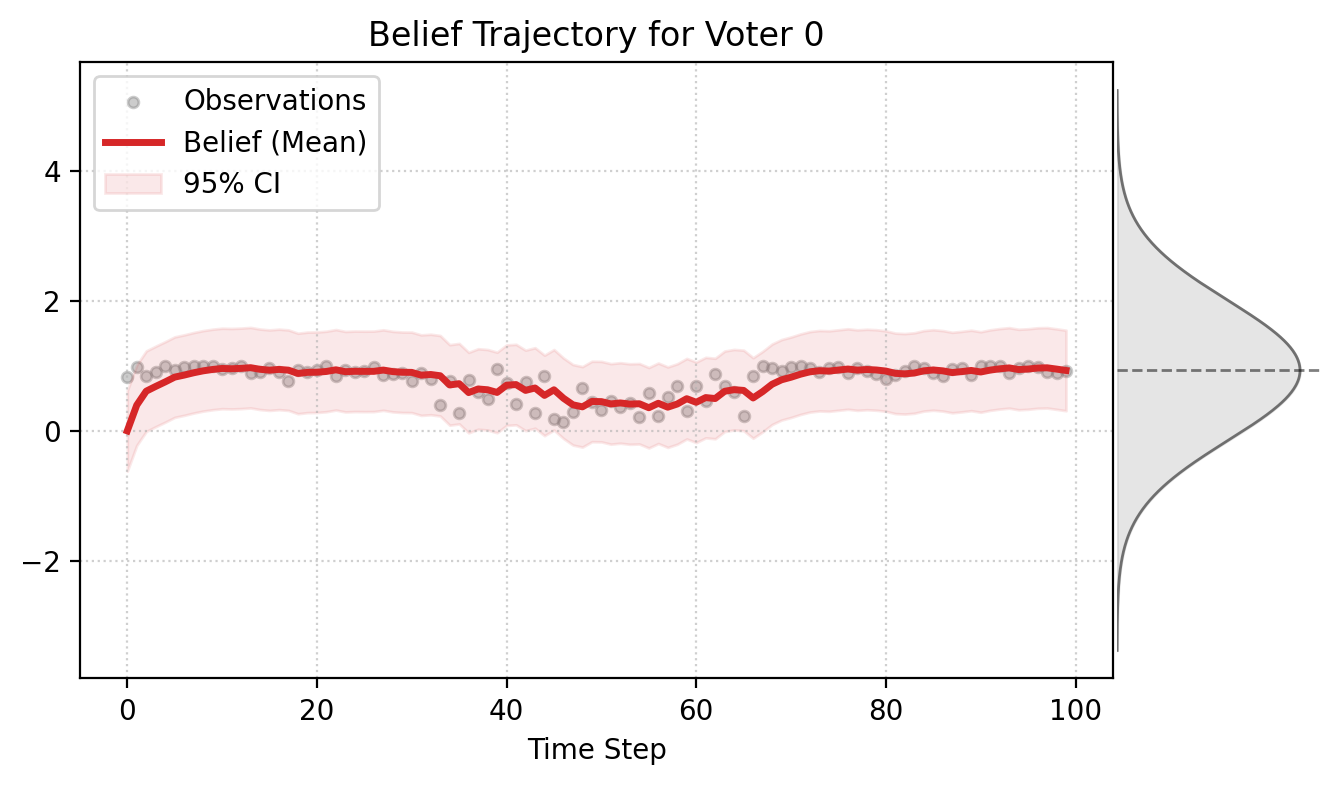

In [24]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# How to create observations manually?

To replicate the data structure expected by your pipeline without using the generator, you can use NumPy. Here are three ways to do it:

In [25]:
# Example: 3 time steps, 2 nodes
manual_obs = np.array(
    [
        [0.10, 0.95],  # Time t=0: Node 0 is low, Node 1 is high
        [
            0.20,
            0.90,
        ],  # Time t=1   (clamped to [0,1] -- the original 3.20 violated the invariant)
        [0.50, 0.50],  # Time t=2: Both converge
    ]
)

print(f"Shape: {manual_obs.shape}")
# Output: (3, 2) -> (n_steps, n_nodes)

Shape: (3, 2)


In [26]:
# Initialize environment
env = Environment(config)
env.input_data = manual_obs
env.num_simulations = NUM_SIMULATIONS
env._run_multi_agent_inference()

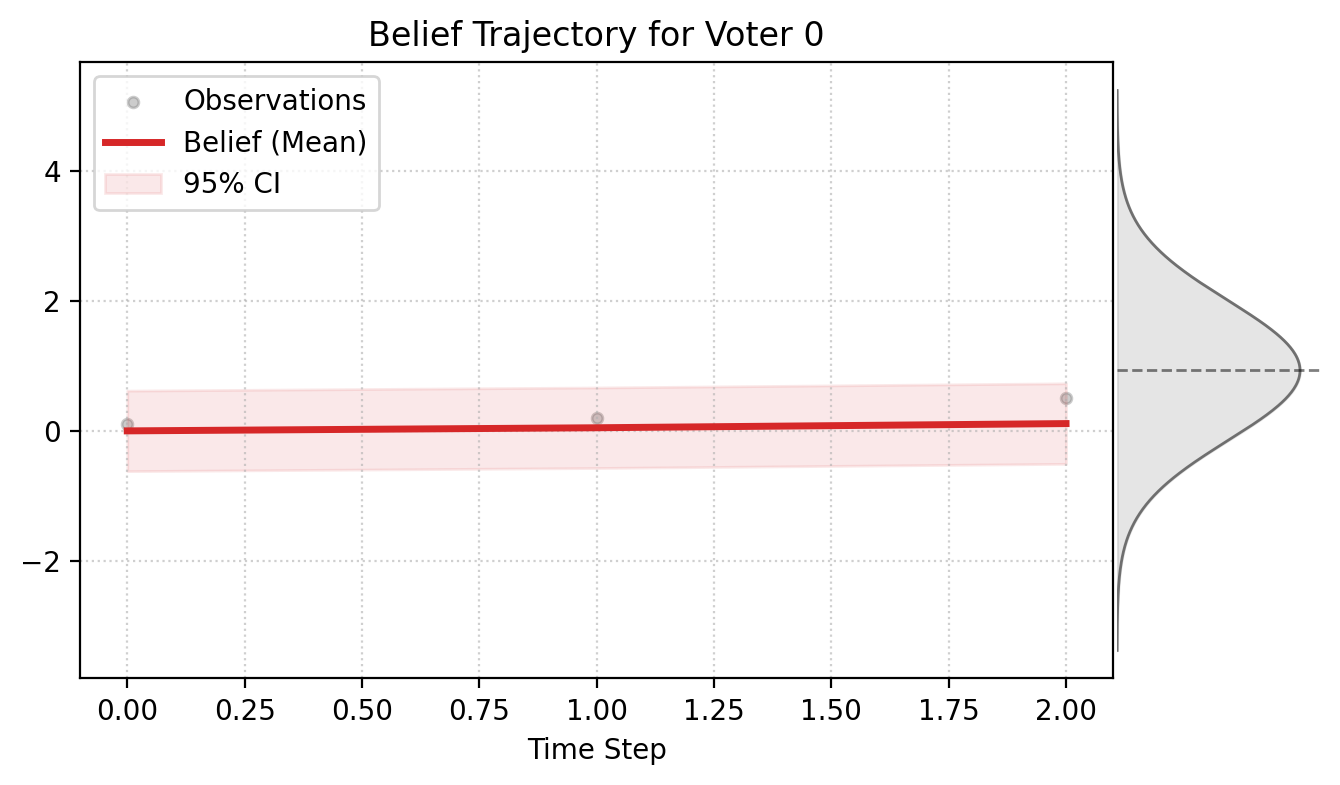

In [27]:
traj_data = get_voter_trajectory_data(env, voter_id=0)
fig, ax1, ax2 = plot_belief_trajectory(**traj_data)

# Volatility

ECI has two distinct volatilities in the model:

1. **Agent volatility** (`tonic_volatility_mean`). Each voter's *prior* on how variable the world is. Internally, this is propagated to the **X2 volatility parent** of every HGF state node — not to the state node itself. A common pitfall is to write `tonic_volatility` on `network.input_idxs` (X1), where it is silently ignored.
2. **World volatility** (`obs_dispersion`, `obs_shock_pattern`). The actual turbulence of the observation stream the agents are exposed to.

When prior matches reality, posteriors converge sharply. When they mismatch, agents are miscalibrated — and through the precision-weighted softmax, this changes how decisively they vote.


## 1. The three world regimes

`generate_observations` produces three qualitatively different signals depending on `scenario` and `shock_pattern`.

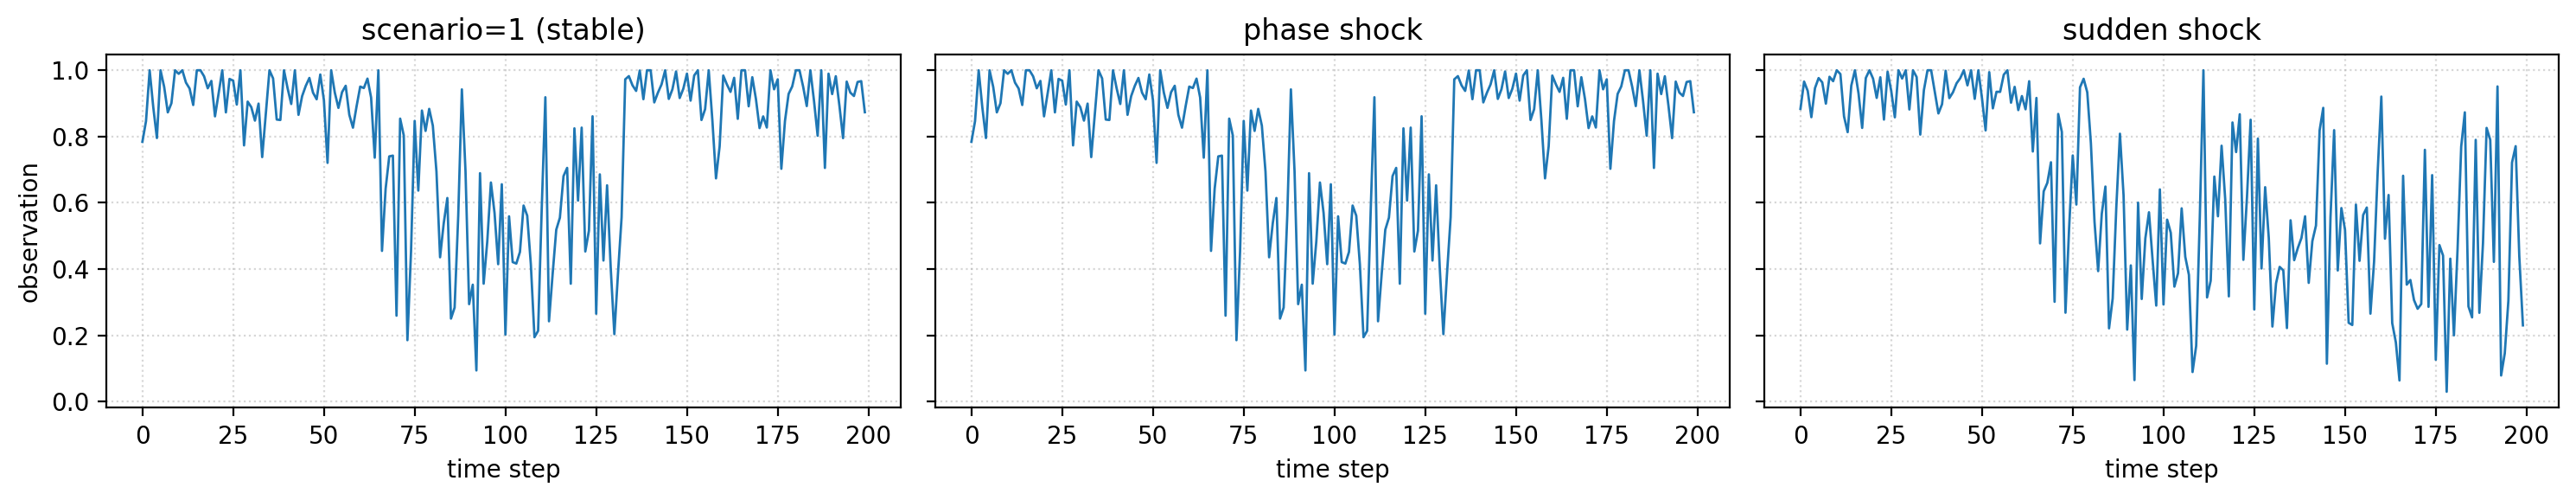

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3), sharey=True)
regimes = [
    ("scenario=1 (stable)", dict(scenario=1)),
    ("phase shock", dict(scenario=2, shock_pattern="phase")),
    ("sudden shock", dict(scenario=2, shock_pattern="sudden")),
]
for ax, (label, kwargs) in zip(axes, regimes):
    obs = generate_observations(
        n_nodes=1, n_steps=200, dispersion=1.0, seed=42, **kwargs
    )
    ax.plot(obs[:, 0], lw=1, color="#1f77b4")
    ax.set_title(label)
    ax.set_xlabel("time step")
    ax.grid(True, ls=":", alpha=0.5)
axes[0].set_ylabel("observation")
plt.tight_layout()
plt.show()

## 2. Effect of `tonic_volatility` on a single agent

Two agents see the same noisy world; only their `tonic_volatility_mean` differs. Low-tvm = "I expect a stable world", high-tvm = "I expect rapid change".

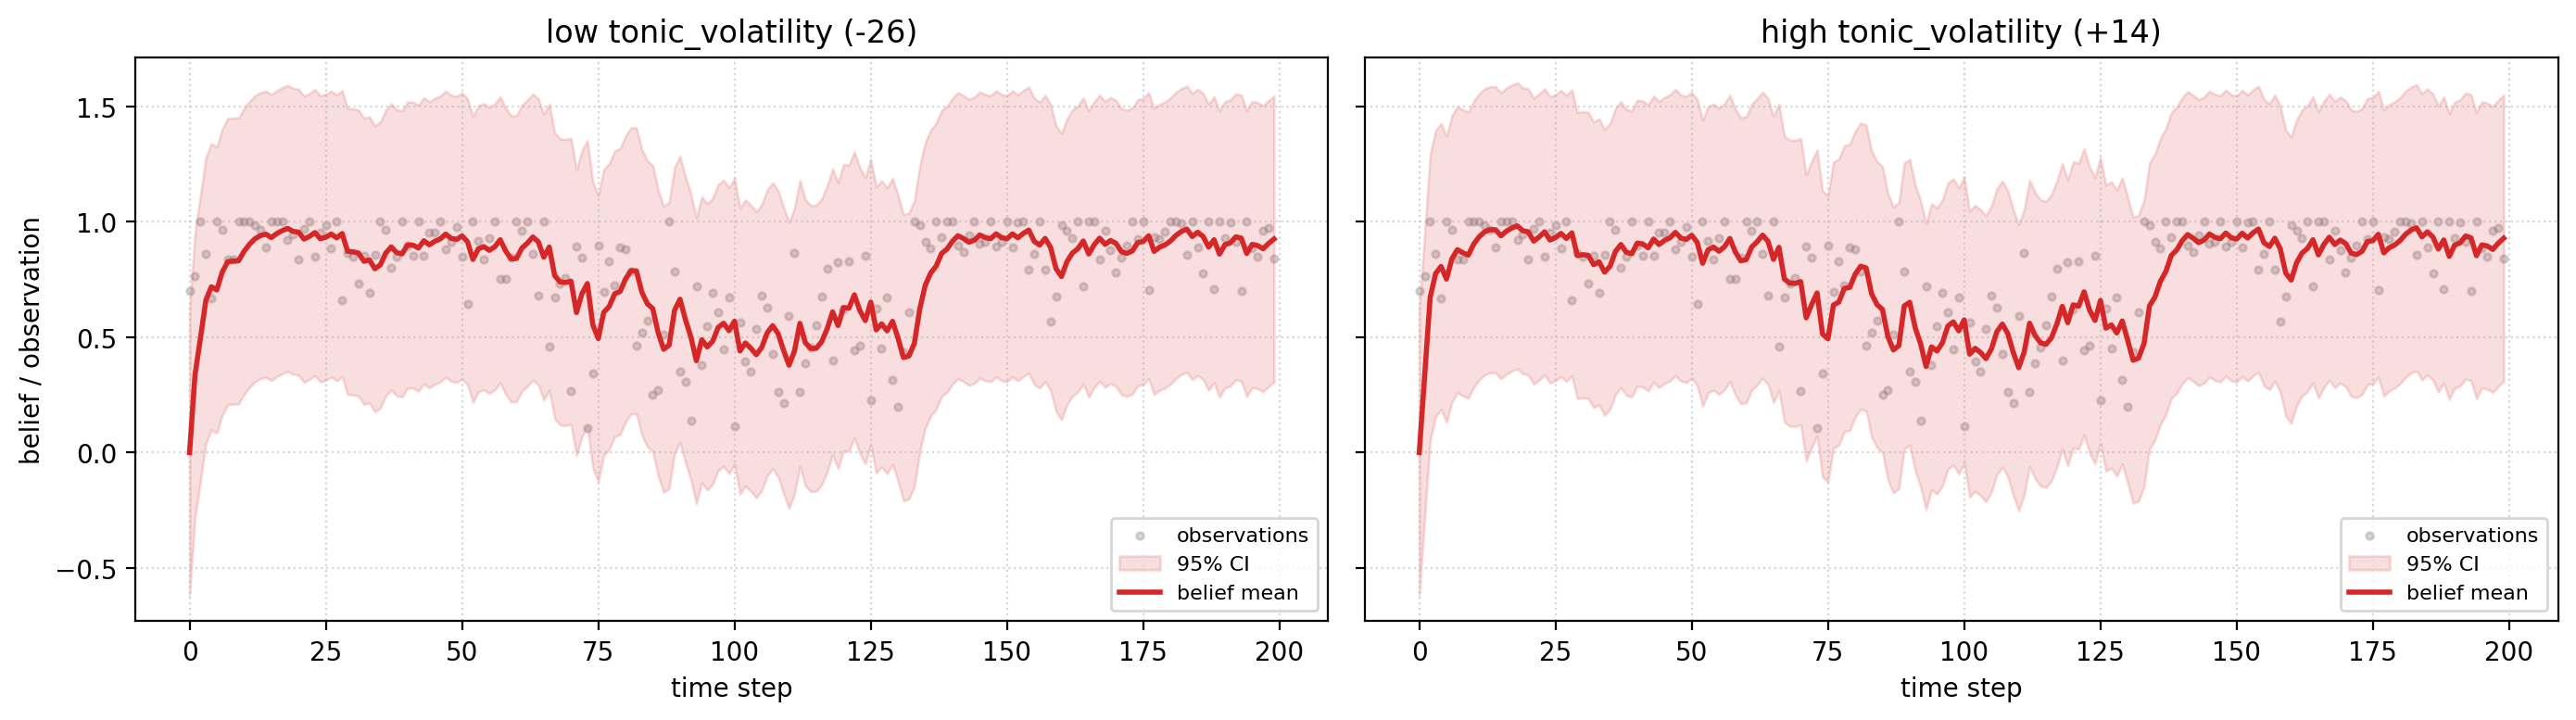

In [29]:
env_low = Environment(
    EnvConfig(
        num_voters=1,
        num_candidates=2,
        num_preferences=1,
        num_steps=200,
        scenario=1,
        tonic_volatility_mean=-26.0,
        obs_dispersion=2.0,
        seed=42,
    )
)
env_high = Environment(
    EnvConfig(
        num_voters=1,
        num_candidates=2,
        num_preferences=1,
        num_steps=200,
        scenario=1,
        tonic_volatility_mean=14.0,
        obs_dispersion=2.0,
        seed=42,
    )
)
for e in (env_low, env_high):
    e._run_multi_agent_inference()

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, env, title in [
    (axes[0], env_low, "low tonic_volatility (-26)"),
    (axes[1], env_high, "high tonic_volatility (+14)"),
]:
    traj = get_voter_trajectory_data(env, voter_id=0)
    t = np.arange(len(traj["observations"]))
    mean = np.asarray(traj["expected_mean"])
    ci = 1.96 / np.sqrt(np.maximum(np.asarray(traj["precisions"]), 1e-9))
    ax.scatter(t, traj["observations"], s=8, c="gray", alpha=0.3, label="observations")
    ax.fill_between(
        t, mean - ci, mean + ci, color="#d62728", alpha=0.15, label="95% CI"
    )
    ax.plot(t, mean, color="#d62728", lw=2, label="belief mean")
    ax.set_title(title)
    ax.set_xlabel("time step")
    ax.grid(True, ls=":", alpha=0.5)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_ylabel("belief / observation")
plt.tight_layout()
plt.show()

**Reading:** the low-tvm agent (left) keeps a wide CI band around a slow-moving belief — observations are absorbed cautiously. The high-tvm agent (right) tracks observations more aggressively and ends with a tighter CI.

## 3. The mismatch grid

The interesting regime is the **interaction** between the agent's prior and the world's volatility. We build a 2×2 grid (low/high prior × calm/noisy world).

In [30]:
priors = {"low_vol_agent": 14.0, "high_vol_agent": -26.0}
worlds = {"calm_world": 0.1, "noisy_world": 8.0}
prior_colors = {"low_vol_agent": "#1f77b4", "high_vol_agent": "#d62728"}

envs = {
    (p, w): Environment(
        EnvConfig(
            num_voters=2,
            num_candidates=2,
            num_preferences=1,
            num_steps=200,
            scenario=1,
            tonic_volatility_std=1.0,
            tonic_volatility_mean=tvm,
            obs_dispersion=disp,
            seed=42,
        )
    )
    for p, tvm in priors.items()
    for w, disp in worlds.items()
}
for env in envs.values():
    env._run_multi_agent_inference()

### 3a. Belief trajectories per cell

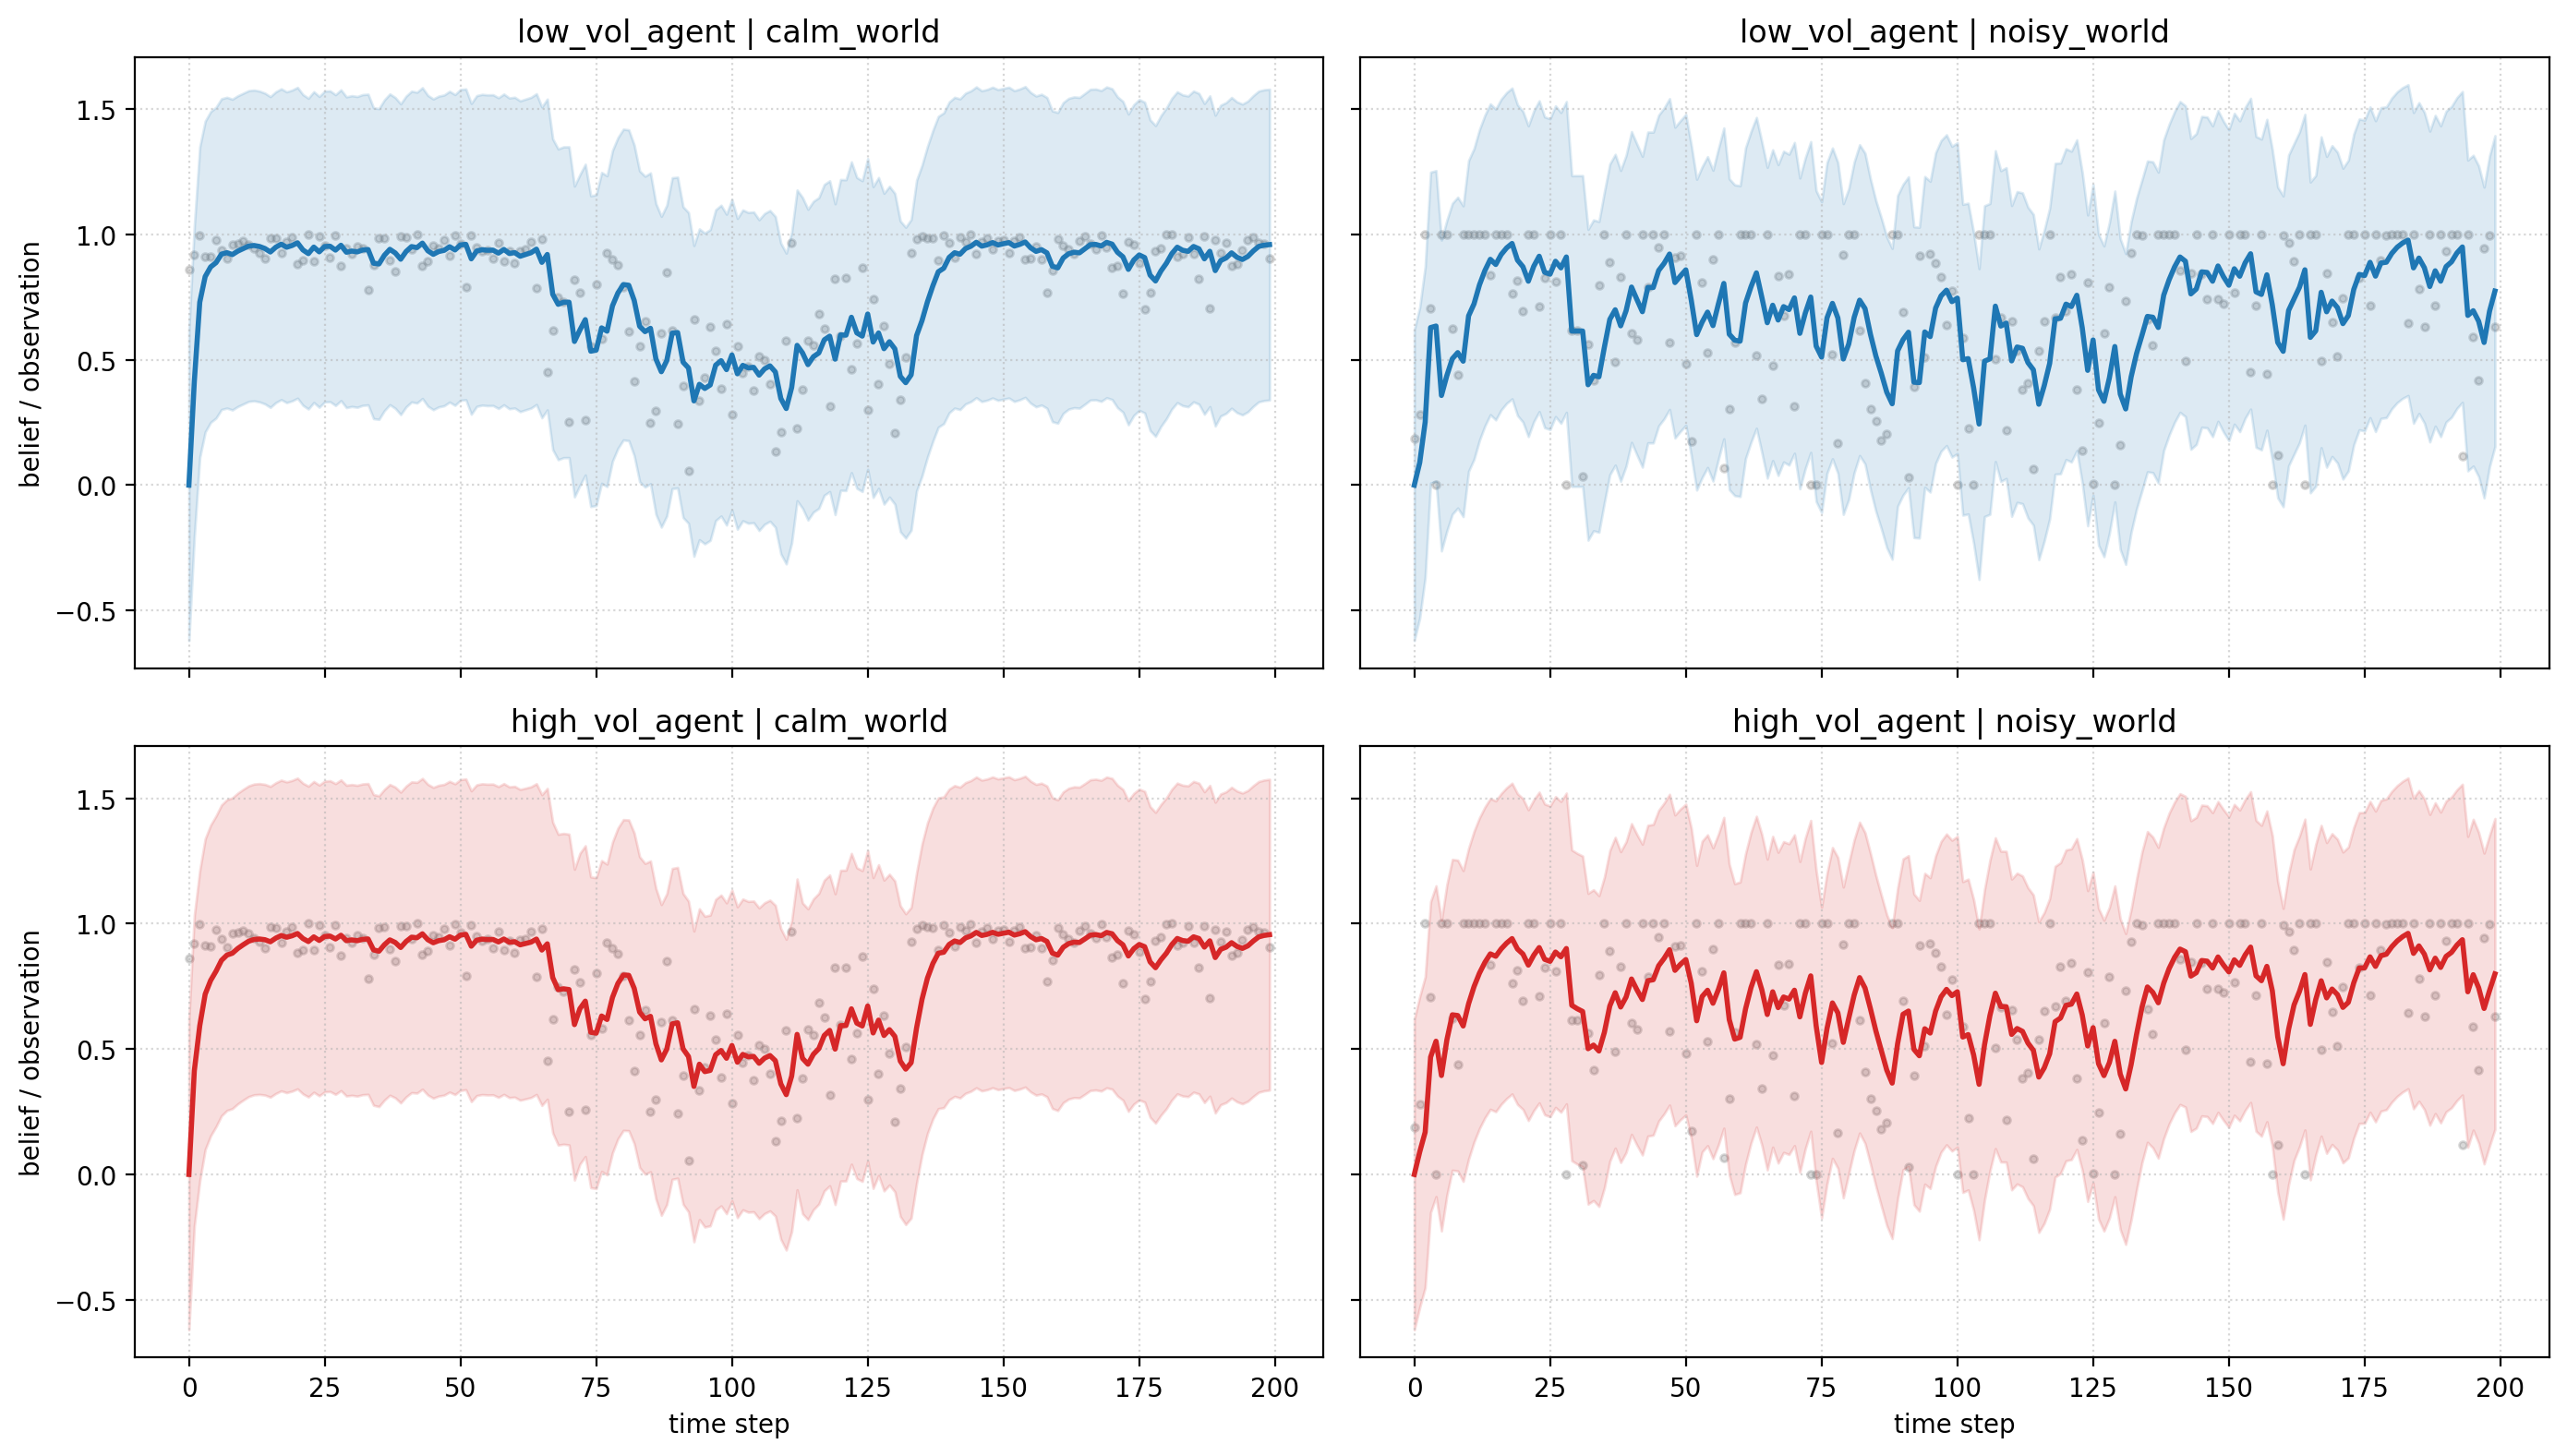

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for i, p in enumerate(priors):
    for j, w in enumerate(worlds):
        ax = axes[i, j]
        traj = get_voter_trajectory_data(envs[(p, w)], voter_id=0)
        t = np.arange(len(traj["observations"]))
        mean = np.asarray(traj["expected_mean"])
        ci = 1.96 / np.sqrt(np.maximum(np.asarray(traj["precisions"]), 1e-9))
        c = prior_colors[p]

        ax.scatter(t, traj["observations"], s=8, c="gray", alpha=0.3)
        ax.fill_between(t, mean - ci, mean + ci, color=c, alpha=0.15)
        ax.plot(t, mean, color=c, lw=2)
        ax.set_title(f"{p} | {w}")
        ax.grid(True, ls=":", alpha=0.5)

for ax in axes[-1, :]:
    ax.set_xlabel("time step")
for ax in axes[:, 0]:
    ax.set_ylabel("belief / observation")
plt.tight_layout()
plt.show()

### 3b. Posterior precision over time (where divergence shows)

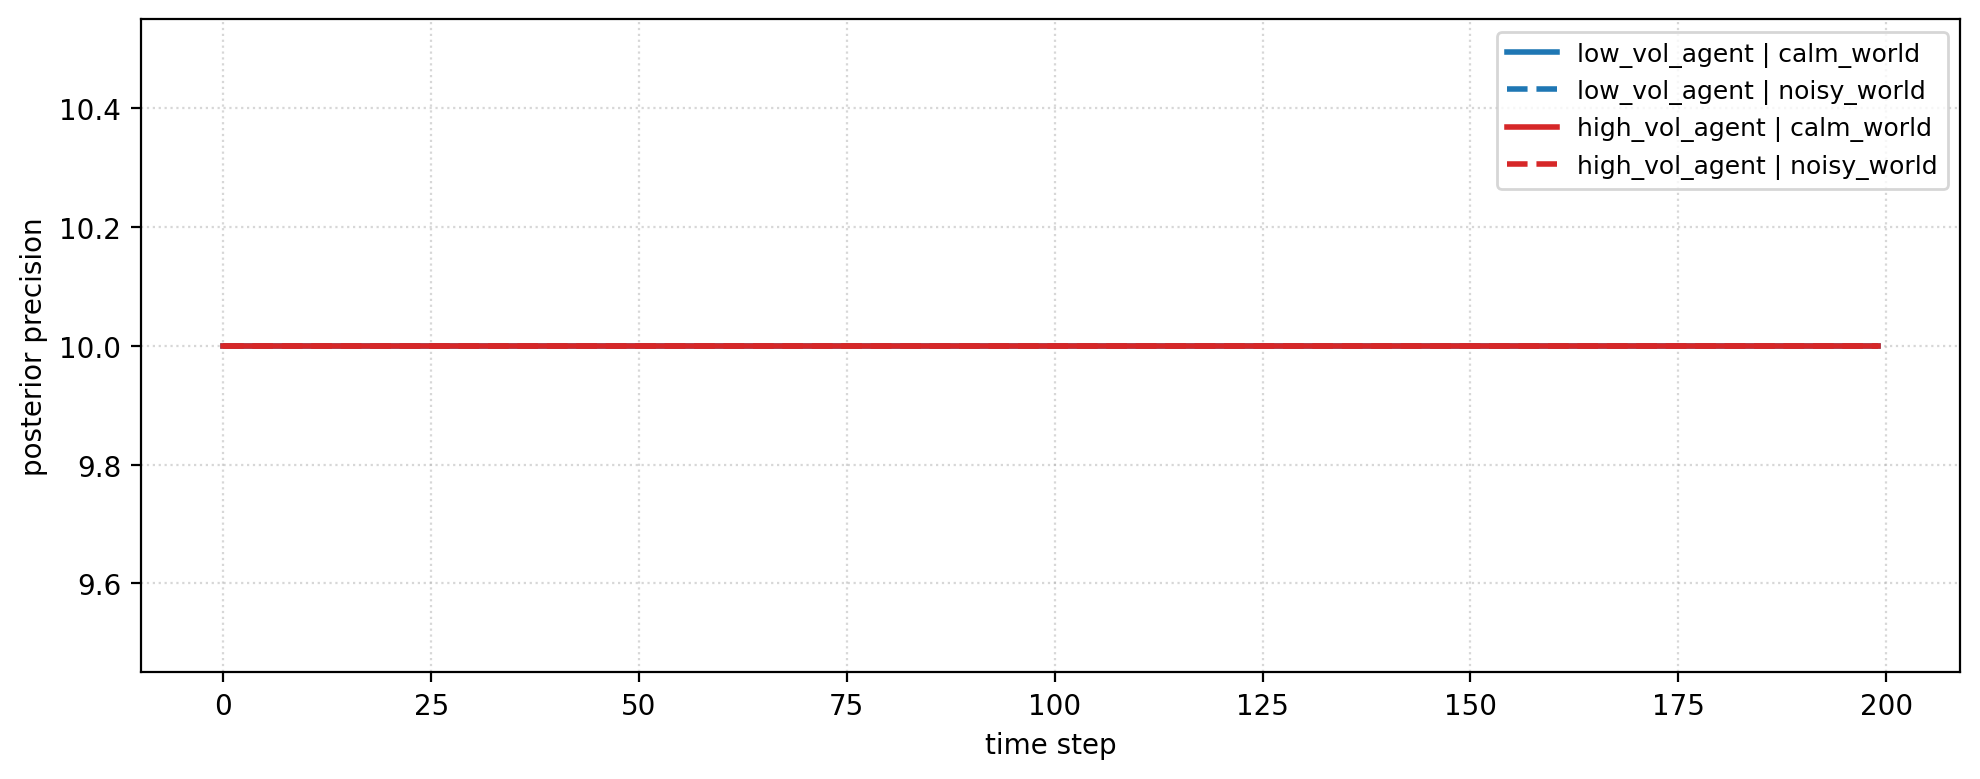

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
for (p, w), env in envs.items():
    traj = get_voter_trajectory_data(env, voter_id=0)
    style = "-" if w == "calm_world" else "--"
    ax.plot(
        traj["precisions"],
        color=prior_colors[p],
        linestyle=style,
        lw=2,
        label=f"{p} | {w}",
    )
ax.set_xlabel("time step")
ax.set_ylabel("posterior precision")
ax.legend(loc="best", fontsize=9)
ax.grid(True, ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

### 3c. End-of-trajectory summary

In [33]:
summary = []
for (p, w), env in envs.items():
    data = _extract_env_data_vectorized(env)
    summary.append(
        {
            "agent_prior": p,
            "world": w,
            "final_posterior_precision": float(
                jnp.sum(data["beliefs"]["precision"], axis=-1)[0]
            ),
            "pref_belief_gap": float(_get_pref_belief_gap(data)[0]),
        }
    )
print(pd.DataFrame(summary).round(3).to_string(index=False))

   agent_prior       world  final_posterior_precision  pref_belief_gap
 low_vol_agent  calm_world                      9.413            1.006
 low_vol_agent noisy_world                      5.511            0.720
high_vol_agent  calm_world                      6.691            0.847
high_vol_agent noisy_world                      4.659            0.649


**Reading the grid:** the diagonal (matched prior and world) tends to produce sharp posteriors and small `pref_belief_gap`. The off-diagonal is *miscalibrated* — wide posteriors, large dissatisfaction. This is the active-inference signature of model mis-specification.

## 4. From beliefs to votes

ECI's voting score is a **precision-weighted softmax**:

$$\text{score}_{i,c} = -\,\tau_i \cdot D_{\text{KL}}(\kappa_c \,\|\, \pi_i)$$

where $\tau_i$ is voter $i$'s posterior precision (sum across preference dimensions), $\kappa_c$ is candidate $c$'s policy, and $\pi_i$ is voter $i$'s preference. The vote distribution is then $\text{softmax}(\text{score}_{i,:})$.

A high-$\tau$ voter has a sharp softmax and votes decisively. A low-$\tau$ voter has a near-uniform softmax — effectively abstains. The **entropy** of the vote distribution is a clean way to summarize this.

In [34]:
results = []
for (p, w), env in envs.items():
    data = _extract_env_data_vectorized(env)
    tau = jnp.sum(data["beliefs"]["precision"], axis=-1)
    gap = _get_pref_candidate_gap(data)
    probs = jax.nn.softmax(-tau[:, None] * gap, axis=1)
    H = float(entropy(np.asarray(probs[0])))
    results.append(
        {
            "agent_prior": p,
            "world": w,
            "posterior_precision": float(tau[0]),
            "vote_entropy": H,
        }
    )
print(pd.DataFrame(results).round(3).to_string(index=False))

   agent_prior       world  posterior_precision  vote_entropy
 low_vol_agent  calm_world                9.413         0.691
 low_vol_agent noisy_world                5.511         0.693
high_vol_agent  calm_world                6.691         0.692
high_vol_agent noisy_world                4.659         0.693


**Reading:** higher `posterior_precision` produces lower `vote_entropy` (sharper vote). Calibrated voters drive the collective decision because their votes carry more information; miscalibrated voters effectively abstain.

## Take-away

- Posterior precision — the agent's confidence after HGF inference — is what the precision-weighted softmax reads.
- **Calibrated** voters (matched prior + world) have sharp posteriors and vote decisively.
- **Miscalibrated** voters have diffuse posteriors and vote almost uniformly.
- The next tutorial sweeps this 2D grid across 30 seeds and 1000 voters to measure how miscalibration biases collective outcomes under plurality vs quadratic voting.

This is the predictive-coding analog of intensity-weighted aggregation: what looks like "intense voters dominating" at the population level is, mechanistically, just precision-weighted softmax composition.
